# Model Performance Overview

**Feeds:** RQ1 (overall PT vs EN reliability). Also provides the span-level
F1 baseline that notebook 03 compares against for the span-vs-attribute
ceiling gap (RQ3).

Uses `results/test/{portuguese,english}/results.csv`, filtered to the best
template per (model, language) from `best_templates.json` (notebook 01).


In [1]:
import sys
sys.path.insert(0, ".")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import _common as c

plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_rows", 100)


In [2]:
best_templates = c.load_best_templates()
test_results = pd.concat([c.load_results("test", lang) for lang in c.LANGUAGE_ORDER], ignore_index=True)
best_test = c.filter_to_best_templates(test_results, best_templates)
best_test[["language", "model", "template", "precision", "recall", "f1", "f1_r"]].sort_values(["language", "model"])


[filter_to_best_templates] english/qwen3_4b: prompt_selection best template ('cls_exp') has no matching rows here; falling back to the single template actually run in this stage ('cls_def_exp').
[filter_to_best_templates] portuguese/qwen3_4b: prompt_selection best template ('ext_exp') has no matching rows here; falling back to the single template actually run in this stage ('cls_def_exp').


,language,model,template,precision,recall,f1,f1_r
3,english,gemini,cls_def_exp,0.534928,0.546124,0.540468,0.752367
4,english,gemma3_1b,ext_def_exp,0.227782,0.118217,0.155652,0.415651
5,english,qwen25_14b,cls_exp,0.309729,0.181395,0.228795,0.674371
6,english,qwen3_4b,cls_def_exp,0.273568,0.240698,0.256082,0.597985
0,portuguese,gemini,cls_def_exp,0.569416,0.548450,0.558736,0.800158
1,portuguese,gemma3_1b,ext_def_exp,0.257314,0.150000,0.189520,0.543525
2,portuguese,qwen25_14b,cls_exp,0.337013,0.177519,0.232546,0.739365
7,portuguese,qwen3_4b,cls_def_exp,0.291906,0.216667,0.248721,0.657510


## F1 and F1-r leaderboard, by model and language

Saved C:\Users\davib\Desktop\MSc_DataScience\thesis\gpt_struct_me\report\Figures\results\02_f1_leaderboard.pdf


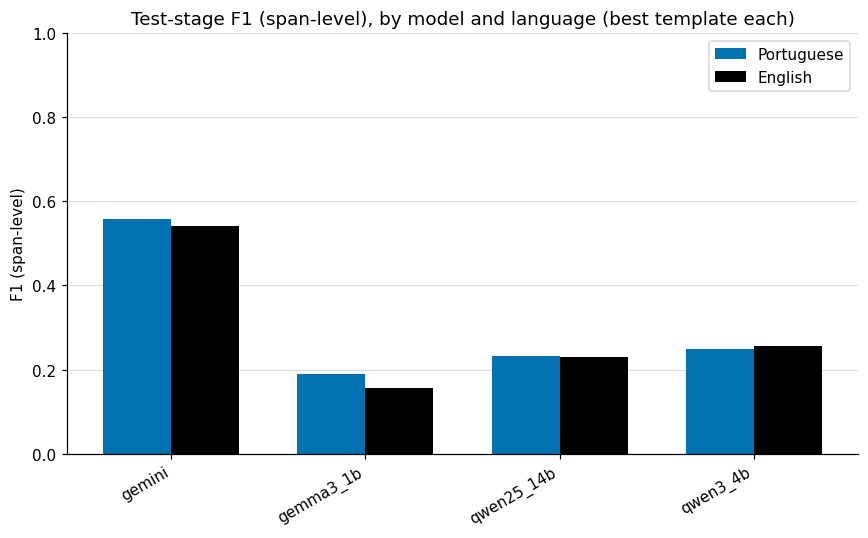

In [3]:
def plot_leaderboard(metric, ylabel, fname):
    fig, ax = plt.subplots(figsize=(8, 5))
    x = np.arange(len(c.MODEL_ORDER))
    width = 0.35
    for i, lang in enumerate(c.LANGUAGE_ORDER):
        sub = best_test[best_test["language"] == lang].set_index("model").reindex(c.MODEL_ORDER)
        ax.bar(x + (i - 0.5) * width, sub[metric].values, width=width, color=c.LANGUAGE_COLORS[lang], label=lang.capitalize())
    ax.set_xticks(x)
    ax.set_xticklabels(c.MODEL_ORDER, rotation=30, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 1)
    ax.set_title(f"Test-stage {ylabel}, by model and language (best template each)")
    ax.legend()
    c.style_axis(ax)
    c.save_fig(fig, fname)
    plt.show()


plot_leaderboard("f1", "F1 (span-level)", "02_f1_leaderboard")


Saved C:\Users\davib\Desktop\MSc_DataScience\thesis\gpt_struct_me\report\Figures\results\02_f1r_leaderboard.pdf


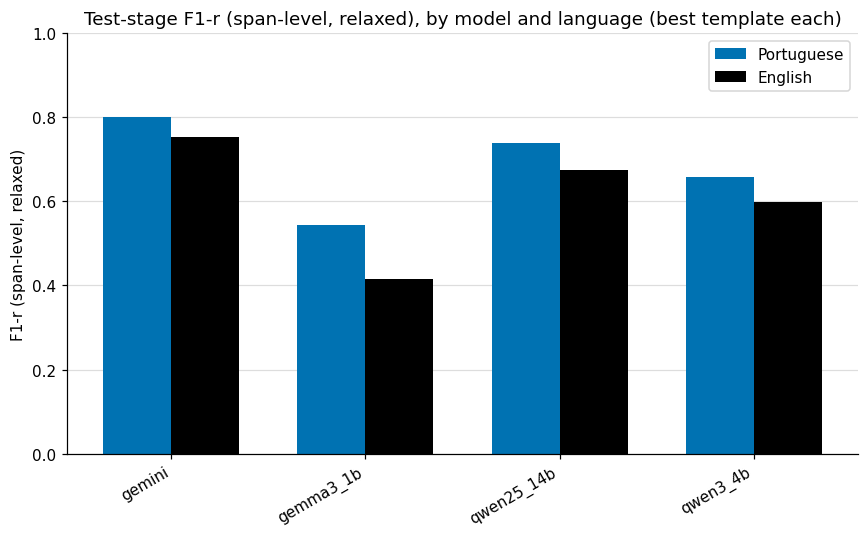

In [4]:
plot_leaderboard("f1_r", "F1-r (span-level, relaxed)", "02_f1r_leaderboard")

## Synthesis

- Feeds **RQ1**: overall test-stage reliability per model, PT vs EN, using each model's own best prompt template (from notebook 01).
- `llama32_3b` is excluded throughout (see notebook 01's note and `_common.EXCLUDED_MODELS`) -- its results are invalid, not merely missing.
- Missing bars otherwise indicate a (model, language) combination with no test-stage run.
- This span-level F1 is the baseline notebook 03 subtracts the attribute-level (type-aware) F1 from, to quantify the span-vs-attribute ceiling gap for RQ3.
